In [ ]:
import gensim
import numpy as np

FILE_PATH = r"C:\Users\Asus\OneDrive\Documents\word translation\cc.en.300.vec"
VOCAB_LIMIT = 1000000

print("Loading embeddings... ")
model = gensim.models.KeyedVectors.load_word2vec_format(
    FILE_PATH,
    binary=False,
    limit=VOCAB_LIMIT
)
print("Embeddings loaded successfully!")

# Normalize vectors (Pre-calculates L2 norms for speed and mathematical consistency)
model.fill_norms() #||v||
print("Vectors normalized and norms cached.")

def check_vocab_coverage(words_to_test):
    missing = [word for word in words_to_test if word not in model.key_to_index]
    if missing:
        print(f"\n Warning: The following words are NOT in your top {VOCAB_LIMIT}: {missing}")
    else:
        print(f"\n Success: All test words are available in the loaded vocabulary.")

print(f"Total Vocabulary size: {len(model.key_to_index)}")

print("\nVector slice for 'king' (first 10 dimensions):")
print(model["king"][:10])

# Similarity Test
similarity = model.similarity("man", "woman")
print(f"\nSimilarity between 'man' and 'woman': {similarity:.4f}")

# Nearest Neighbors Test
print("\nWords most similar to 'doctor':")
for word, score in model.most_similar("doctor"):
    print(f" - {word}: {score:.4f}")

# Bias Word Coverage Check
bias_test_words = ["doctor", "nurse", "programmer", "homemaker", "engineer", "receptionist"]
check_vocab_coverage(bias_test_words)

Loading embeddings... 
Embeddings loaded successfully!
Vectors normalized and norms cached.
Total Vocabulary size: 1000000

Vector slice for 'king' (first 10 dimensions):
[-0.0264 -0.0438 -0.0522  0.025   0.16    0.005   0.0025 -0.0163 -0.0662
 -0.0017]

Similarity between 'man' and 'woman': 0.7658

Words most similar to 'doctor':
 - physician: 0.7759
 - doctors: 0.7071
 - gynecologist: 0.7047
 - docto: 0.7047
 - pediatrician: 0.6923
 - doctor.I: 0.6786
 - doctor.: 0.6720
 - docter: 0.6714
 - physcian: 0.6711
 - pharmacist: 0.6683

 Success: All test words are available in the loaded vocabulary.


In [15]:

# v(b) - v(a) + v(c)

def run_analogy(a, b, c):
    result = model.most_similar(
        positive=[b, c],
        negative=[a],
        topn=1
    )
    return result[0]

# Diverse analogy examples
analogies = [
    ("man", "king", "woman"),       # Gender / Royalty
    ("france", "paris", "germany"), # Capital Cities
    ("tall", "taller", "short"),    # Comparative Adjectives
    ("walk", "walking", "swim"),    # Verb Morphology
    ("good", "best", "bad")         # Superlatives
]

print("\n--- Analogy Results ---")

for a, b, c in analogies:
    word, score = run_analogy(a, b, c)

    print(f"{a} : {b} :: {c} : {word} (score = {score:.4f})")


--- Analogy Results ---
man : king :: woman : queen (score = 0.7555)
france : paris :: germany : munich (score = 0.6885)
tall : taller :: short : shorter (score = 0.7445)
walk : walking :: swim : swimming (score = 0.8183)
good : best :: bad : worst (score = 0.7586)


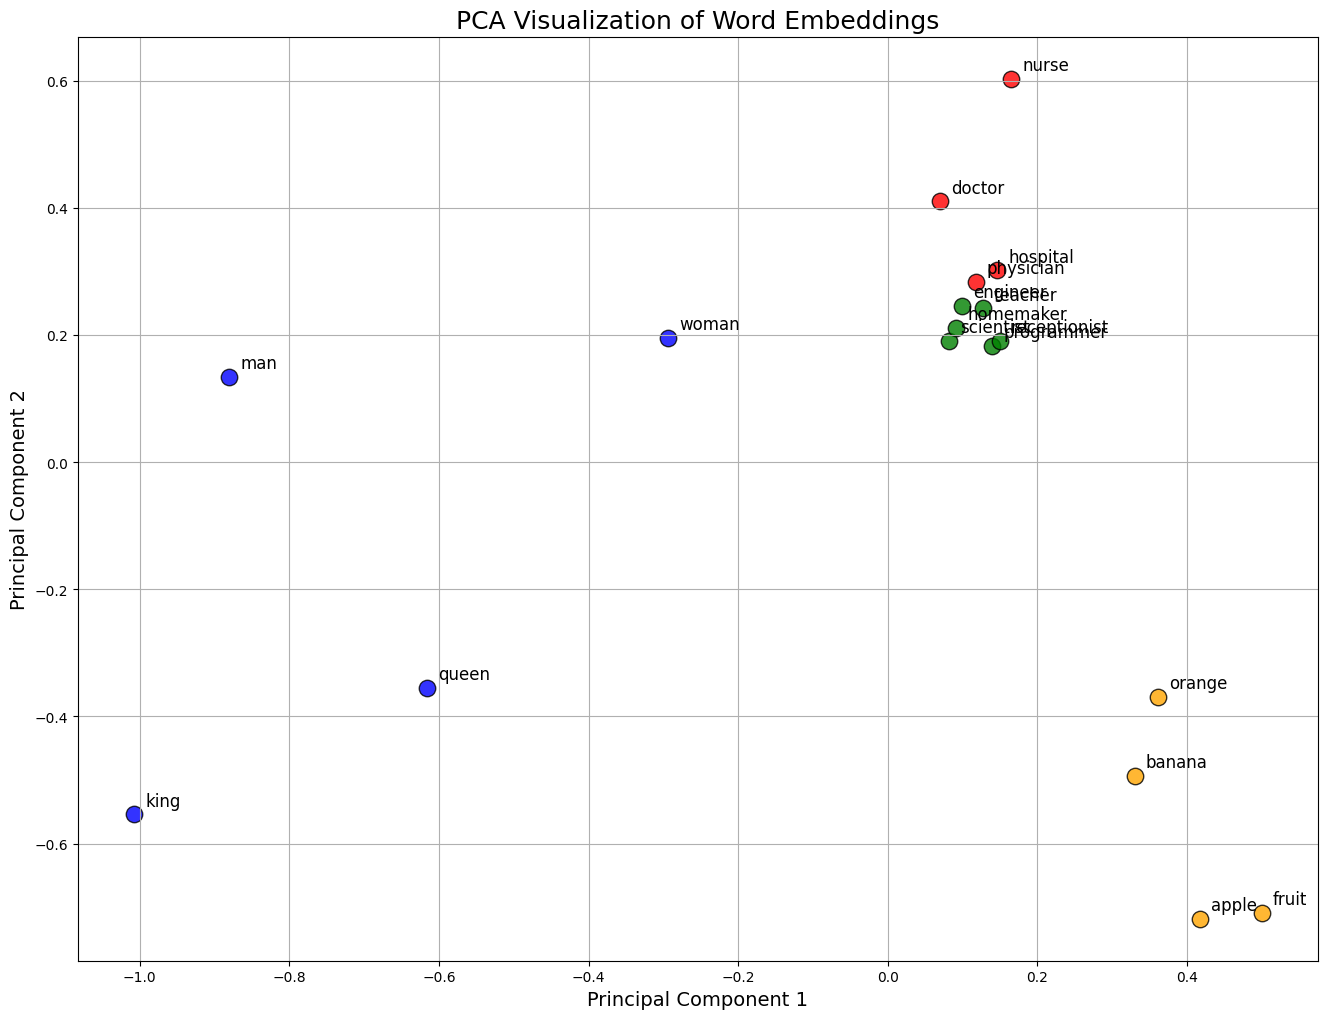

In [18]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA

# PCA Visualization Function
def plot_words(words):

    # Keep valid words only
    valid_words = [w for w in words if w in model.key_to_index]

    # Get vectors
    word_vectors = np.array([model[w] for w in valid_words])

    # PCA reduction
    pca = PCA(n_components=2)
    reduced = pca.fit_transform(word_vectors)

    # Word groups for coloring
    royalty = {"king", "queen", "man", "woman"}
    medical = {"doctor", "nurse", "physician", "hospital"}
    professions = {"engineer", "programmer", "scientist",
                   "teacher", "receptionist", "homemaker"}
    fruits = {"apple", "banana", "orange", "fruit"}

    plt.figure(figsize=(16, 12))

    # Plot each word individually
    for i, word in enumerate(valid_words):

        x = reduced[i, 0]
        y = reduced[i, 1]

        # Assign colors
        if word in royalty:
            color = "blue"
        elif word in medical:
            color = "red"
        elif word in professions:
            color = "green"
        else:
            color = "orange"

        # Draw point
        plt.scatter(
            x,
            y,
            color=color,
            s=140,
            edgecolors='black',
            alpha=0.8
        )

        # Add label with offset
        plt.annotate(
            word,
            (x, y),
            fontsize=12,
            xytext=(8, 6),
            textcoords='offset points'
        )

    plt.title("PCA Visualization of Word Embeddings", fontsize=18)
    plt.xlabel("Principal Component 1", fontsize=14)
    plt.ylabel("Principal Component 2", fontsize=14)

    plt.grid(True)
    plt.show()


# Words to visualize
words_to_plot = [

    # Royalty / Gender
    "king", "queen", "man", "woman",

    # Medical
    "doctor", "nurse", "physician", "hospital",

    # Professions
    "engineer", "programmer", "scientist",
    "teacher", "receptionist", "homemaker",

    # Fruits
    "apple", "banana", "orange", "fruit"
]

plot_words(words_to_plot)

In [20]:
import numpy as np

def get_direction(model, pairs):
    diffs = [model[p[0]] - model[p[1]] for p in pairs]
    return np.mean(diffs, axis=0)

# Direction A: Gender (Female -> Male)
gender_pairs = [('woman', 'man'), ('female', 'male'), ('she', 'he'), ('mother', 'father')]
gender_axis = get_direction(model, gender_pairs)

# Direction B: Age (Old -> Young)
age_pairs = [('old', 'young'), ('elderly', 'youth'), ('retired', 'student'), ('ancient', 'modern')]
age_axis = get_direction(model, age_pairs)

# Direction C: Wealth/Status (Rich -> Poor)
wealth_pairs = [('rich', 'poor'), ('wealthy', 'impoverished'), ('expensive', 'cheap'), ('luxury', 'budget')]
wealth_axis = get_direction(model, wealth_pairs)

axes = {
    "Gender (Pos:Fem)": gender_axis,
    "Age (Pos:Old)": age_axis,
    "Wealth (Pos:Rich)": wealth_axis
}

# 2. Bias Quantification with Neutrality Threshold
professions = ["doctor", "nurse", "programmer", "teacher", "engineer"]
threshold = 0.05  # Scores between -0.05 and 0.05 are considered neutral

print(f"{'Profession':<12} | {'Axis':<15} | {'Score':<10} | {'Interpretation'}")
print("-" * 60)

for word in professions:
    for axis_name, axis_vec in axes.items():
        # proj = (v · b) / ||b||
        score = np.dot(model[word], axis_vec) / np.linalg.norm(axis_vec)
        
        if score > threshold:
            label = "Positive-aligned"
        elif score < -threshold:
            label = "Negative-aligned"
        else:
            label = "Neutral"
            
        print(f"{word:<12} | {axis_name:<15} | {score:>10.4f} | {label}")
    print("-" * 60)


Profession   | Axis            | Score      | Interpretation
------------------------------------------------------------
doctor       | Gender (Pos:Fem) |    -0.1692 | Negative-aligned
doctor       | Age (Pos:Old)   |     0.0730 | Positive-aligned
doctor       | Wealth (Pos:Rich) |    -0.0338 | Neutral
------------------------------------------------------------
nurse        | Gender (Pos:Fem) |     0.0308 | Neutral
nurse        | Age (Pos:Old)   |     0.0083 | Neutral
nurse        | Wealth (Pos:Rich) |    -0.0665 | Negative-aligned
------------------------------------------------------------
programmer   | Gender (Pos:Fem) |    -0.0984 | Negative-aligned
programmer   | Age (Pos:Old)   |    -0.0506 | Negative-aligned
programmer   | Wealth (Pos:Rich) |    -0.0113 | Neutral
------------------------------------------------------------
teacher      | Gender (Pos:Fem) |    -0.0829 | Negative-aligned
teacher      | Age (Pos:Old)   |    -0.1050 | Negative-aligned
teacher      | Wealth (Pos:R

In [22]:
def check_analogy(a, b, c):
    # a is to b as c is to ??  ->  (v_b - v_a + v_c)
    results = model.most_similar(positive=[b, c], negative=[a], topn=3)
    print(f"Analogy: {a}:{b} :: {c}:?")
    for i, (word, score) in enumerate(results):
        print(f"  {i+1}. {word:<15} ({score:.4f})")

print("\n--- Stereotype Test Results ---")
test_cases = [
    ("man", "woman", "doctor"),
    ("man", "woman", "boss"),
    ("young", "old", "wise"),
    ("poor", "rich", "successful"),
    ("man", "woman", "programmer")
]

for a, b, c in test_cases:
    check_analogy(a, b, c)


--- Stereotype Test Results ---
Analogy: man:woman :: doctor:?
  1. gynecologist    (0.7013)
  2. physician       (0.6668)
  3. gynocologist    (0.6592)
Analogy: man:woman :: boss:?
  1. bosses          (0.6636)
  2. boss.The        (0.5866)
  3. ex-boss         (0.5470)
Analogy: young:old :: wise:?
  1. addage          (0.4487)
  2. wize            (0.4380)
  3. outdate         (0.4322)
Analogy: poor:rich :: successful:?
  1. succesful       (0.5462)
  2. sucessful       (0.5213)
  3. highly-successful (0.5096)
Analogy: man:woman :: programmer:?
  1. programmers     (0.6289)
  2. programer       (0.6171)
  3. coder           (0.5881)


In [ ]:
import numpy as np

pairs = [('woman', 'man'), ('female', 'male'), ('she', 'he')]
gender_axis = np.mean([model[w] - model[m] for w, m in pairs], axis=0)

def neutralize(word_vector, bias_direction):
    projection = (np.dot(word_vector, bias_direction) / np.dot(bias_direction, bias_direction)) * bias_direction
    return word_vector - projection

professions = ["doctor", "nurse", "programmer", "teacher", "engineer"]
debiased_model = {} # Store our new vectors

for word in professions:
    debiased_model[word] = neutralize(model[word], gender_axis)

print("Debiasing complete for selected professions.")


Debiasing complete for selected professions.


In [23]:
#  Evaluation: Compare Neighbors Before and After
def evaluate_debiasing(word):
    print(f"\n{'='*20} Evaluation for: {word.upper()} {'='*20}")
    
    # Before
    print("BEFORE (Original):")
    for w, s in model.most_similar(word, topn=3):
        print(f"  - {w:<15} (Score: {s:.4f})")
    
    # After
    print("\nAFTER (Debiased):")
    # We use the new vector to find the closest words in the original vocabulary
    for w, s in model.most_similar(positive=[debiased_model[word]], topn=3):
        print(f"  - {w:<15} (Score: {s:.4f})")

# 5. Evaluation: Analogy Comparison
def compare_analogy(target_word, debiased_v):
    print(f"\nAnalogy Test: 'man' is to 'woman' as '{target_word}' is to...")
    
    # Original analogy logic
    orig_res = model.most_similar(positive=['woman', target_word], negative=['man'], topn=1)[0][0]
    
    # Debiased analogy logic (using the engineered vector)
    deb_res = model.most_similar(positive=['woman', debiased_v], negative=['man'], topn=1)[0][0]
    
    print(f"  Original Result: {orig_res}")
    print(f"  Debiased Result: {deb_res}")

for prof in ["doctor", "programmer"]:
    evaluate_debiasing(prof)
    compare_analogy(prof, debiased_model[prof])


==================== Evaluation for: DOCTOR ====================
BEFORE (Original):
  - physician       (Score: 0.7759)
  - doctors         (Score: 0.7071)
  - gynecologist    (Score: 0.7047)

AFTER (Debiased):
  - doctor          (Score: 0.9821)
  - physician       (Score: 0.7574)
  - gynecologist    (Score: 0.7065)

Analogy Test: 'man' is to 'woman' as 'doctor' is to...
  Original Result: gynecologist
  Debiased Result: doctor

==================== Evaluation for: PROGRAMMER ====================
BEFORE (Original):
  - programer       (Score: 0.8050)
  - programmers     (Score: 0.7683)
  - coder           (Score: 0.7400)

AFTER (Debiased):
  - programmer      (Score: 0.9854)
  - programer       (Score: 0.7898)
  - programmers     (Score: 0.7648)

Analogy Test: 'man' is to 'woman' as 'programmer' is to...
  Original Result: programmers
  Debiased Result: programmer


In [9]:
def run_debiased_analogy(a, b, debiased_word):
    # Logic: b - a + debiased_v
    res = model.most_similar(positive=[b, debiased_word], negative=[a], topn=1)
    return res[0][0]

print("\n--- Analogy Comparison: 'man' is to 'woman' as 'doctor' is to... ---")
print(f"Original: {run_analogy('man', 'woman', 'doctor')}") # The old code
print(f"Debiased: {run_debiased_analogy('man', 'woman', debiased_model['doctor'])}")


--- Analogy Comparison: 'man' is to 'woman' as 'doctor' is to... ---
Original: gynecologist
Debiased: doctor


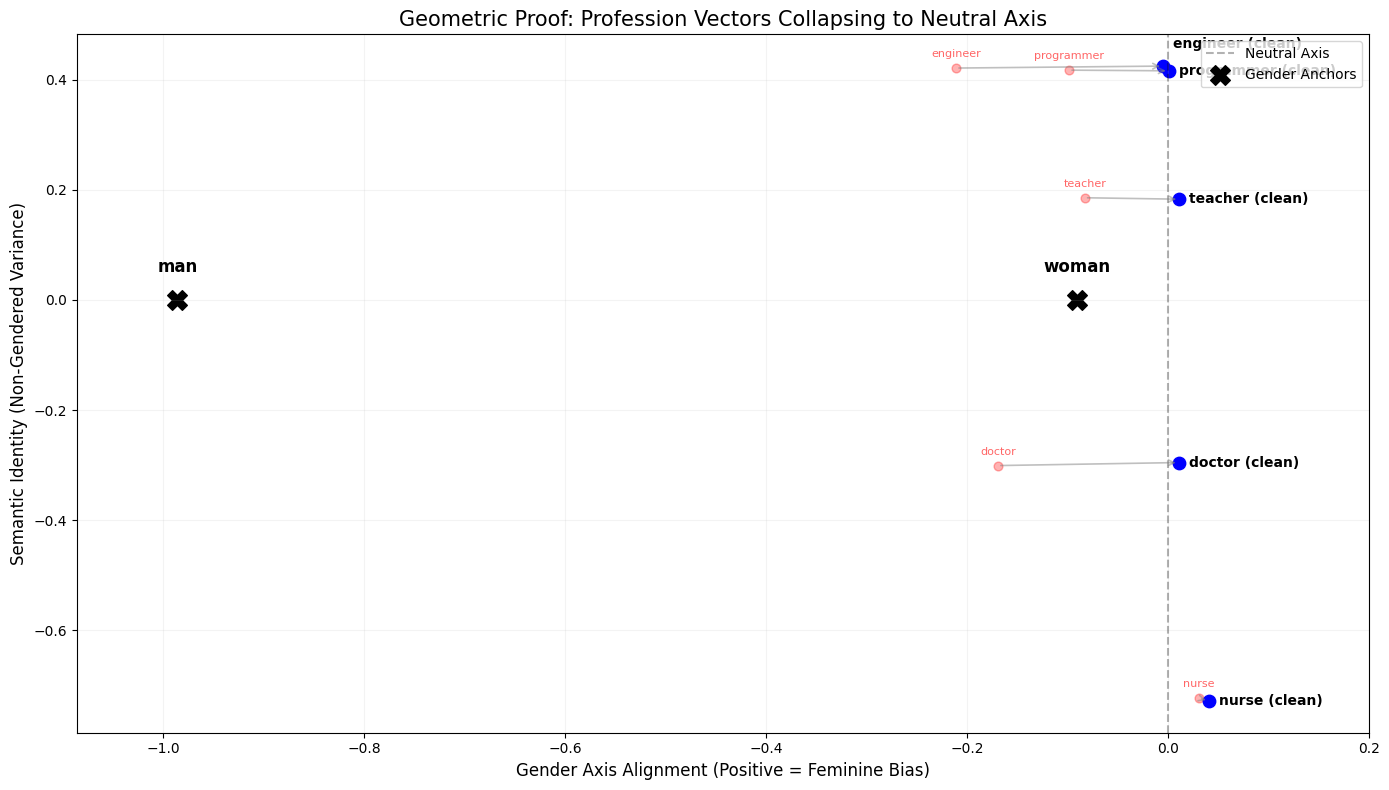

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def plot_final_debiasing_results(model, gender_axis, professions, debiased_vectors):
    """
    Creates a projection plot where the X-axis is the Bias Direction 
    and the Y-axis is the Semantic Residual.
    """
    # 1. Normalize the bias direction
    g_unit = gender_axis / np.linalg.norm(gender_axis)
    
    # 2. Extract vectors
    orig_vecs = np.array([model[w] for w in professions])
    cln_vecs = np.array([debiased_vectors[w] for w in professions])
    
    # 3. Define the Coordinate System
    # X = Alignment with Gender Axis
    # Y = First Principal Component of the non-gendered information
    def get_projection_coords(vecs):
        x = np.dot(vecs, g_unit)
        # Remove gender component to find 'pure' semantic variance for Y-axis
        residuals = vecs - np.outer(x, g_unit)
        pca = PCA(n_components=1)
        y = pca.fit_transform(residuals).flatten()
        return x, y

    x_orig, y_orig = get_projection_coords(orig_vecs)
    x_cln, y_cln = get_projection_coords(cln_vecs)
    
    # Anchor points for reference (Man/Woman)
    x_man = np.dot(model['man'], g_unit)
    x_woman = np.dot(model['woman'], g_unit)

    # 4. Initialize Plot
    plt.figure(figsize=(14, 8))
    plt.axvline(0, color='black', linestyle='--', alpha=0.3, label="Neutral Axis")
    
    # Plot Gender Anchors
    plt.scatter([x_man, x_woman], [0, 0], marker='X', color='black', s=200, label='Gender Anchors')
    plt.text(x_man, 0.05, 'man', fontsize=12, fontweight='bold', ha='center')
    plt.text(x_woman, 0.05, 'woman', fontsize=12, fontweight='bold', ha='center')

    # 5. Plot Professions with Overlap Handling
    # Using a simple offset dictionary to prevent label stacking on the Y-axis
    y_counts = {}

    for i, word in enumerate(professions):
        # Calculate label offset for clean points
        y_rounded = round(y_cln[i], 1)
        offset = y_counts.get(y_rounded, 0)
        y_counts[y_rounded] = offset + 0.04  # Shift next overlapping label up
        
        # Draw Movement Arrow (Red -> Blue)
        plt.annotate('', xy=(x_cln[i], y_cln[i]), xytext=(x_orig[i], y_orig[i]),
                     arrowprops=dict(arrowstyle='->', color='gray', lw=1.2, alpha=0.5))
        
        # Original (Biased) Points
        plt.scatter(x_orig[i], y_orig[i], color='red', alpha=0.3, s=40)
        plt.text(x_orig[i], y_orig[i] + 0.02, word, fontsize=8, color='red', alpha=0.6, ha='center')
        
        # Debiased (Clean) Points
        plt.scatter(x_cln[i], y_cln[i], color='blue', s=80)
        plt.text(x_cln[i] + 0.01, y_cln[i] + offset, f"{word} (clean)", 
                 fontsize=10, fontweight='bold', va='center')

    # 6. Final Formatting
    plt.title("Geometric Proof: Profession Vectors Collapsing to Neutral Axis", fontsize=15)
    plt.xlabel("Gender Axis Alignment (Positive = Feminine Bias)", fontsize=12)
    plt.ylabel("Semantic Identity (Non-Gendered Variance)", fontsize=12)
    
    # Zoom into the relevant data area to avoid the 'cluttered' look of image_57c676.png
    plt.xlim(min(x_orig.min(), x_man) - 0.1, 0.2) 
    
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.15)
    plt.tight_layout()
    plt.show()

# Run the updated visualization
plot_final_debiasing_results(model, gender_axis, professions, debiased_model)

In [33]:
import numpy as np

raw_bias = model['woman'] - model['man']
bias_unit_vec = raw_bias / np.linalg.norm(raw_bias)

def inject_bias(word, lambda_val, bias_vec):
    #v' = v + λb
    v_original = model[word]
    v_biased = v_original + (lambda_val * bias_vec)
    return v_biased

# 2. Experiment with different Lambda values
target = "student"
# 0 = No change, 1.0 = Moderate shift, 3.0 = Extreme shift
lambdas = [0, 1.0, 2.5, 5.0] 

print(f"{'Lambda':<8} | {'Top Neighbors (Shifted Context)'}")
print("-" * 60)

for l in lambdas:
    v_new = inject_bias(target, l, bias_unit_vec)
    # Finding neighbors for the newly engineered vector
    neighbors = model.most_similar(positive=[v_new], topn=3)
    
    neighbor_names = [f"{n[0]} ({n[1]:.2f})" for n in neighbors]
    print(f"λ = {l:<5} | {neighbor_names}")

# 3. Demonstrate Analogy Change
# We inject bias into 'doctor' and see how the standard analogy reacts
lambda_test = 2.0
doctor_biased = inject_bias("doctor", lambda_test, bias_unit_vec)

# Analogy: man is to woman as doctor_biased is to ??
# Formula: v_woman - v_man + v_doctor_biased
result = model.most_similar(positive=['woman', doctor_biased], 
                            negative=['man'], topn=1)

print(f"\n--- Analogy Analysis (λ={lambda_test}) ---")
print(f"Original: man : woman :: doctor : gynecologist")
print(f"Injected: man : woman :: doctor_biased : {result[0][0]}")

Lambda   | Top Neighbors (Shifted Context)
------------------------------------------------------------
λ = 0     | ['student (1.00)', 'students (0.75)', 'student.The (0.69)']
λ = 1.0   | ['student (0.53)', 'students (0.45)', 'Student (0.42)']
λ = 2.5   | ['Nurse-Midwives (0.33)', 'ABSN (0.31)', 'Midwifery (0.30)']
λ = 5.0   | ['Nurse-Midwives (0.31)', 'Midwifery (0.29)', 'IBCLC (0.28)']

--- Analogy Analysis (λ=2.0) ---
Original: man : woman :: doctor : gynecologist
Injected: man : woman :: doctor_biased : Nurse-Midwives


In [34]:
import numpy as np

gender_direction = model['woman'] - model['man']
u_b = gender_direction / np.linalg.norm(gender_direction)

def get_bias_score(word_vector, unit_bias_axis):
    return np.dot(word_vector, unit_bias_axis)

#APPROACH A: Local Debiasing (Selected Professions only)
professions = ["doctor", "nurse", "programmer", "teacher", "engineer"]
local_debiased_model = {}

for word in professions:
    v = model[word]
    # v' = v - (v · u)u
    local_debiased_model[word] = v - np.dot(v, u_b) * u_b

# APPROACH B: Global Debiasing (Entire Embedding Space)
all_vectors = model.vectors
dot_products = np.dot(all_vectors, u_b)
projections = np.outer(dot_products, u_b)
global_matrix_debiased = all_vectors - projections

def get_global_vec(word):
    idx = model.key_to_index[word]
    return global_matrix_debiased[idx]

# 4. COMPARISON: Evaluating the results
# We test a word that was NOT in our local 'professions' list
test_words = ["manager", "captain", "assistant", "queen", "king", "mother"]

print(f"{'Word':<12} | {'Original':<10} | {'Local':<10} | {'Global':<10} | {'Status'}")
print("-" * 75)

for w in test_words:
    orig_s = get_bias_score(model[w], u_b)
    # Check if word was in local list, else it remains original
    loc_vec = local_debiased_model.get(w, model[w])
    loc_s = get_bias_score(loc_vec, u_b)
    glob_s = get_bias_score(get_global_vec(w), u_b)
    
    # Status helps identify 'Collateral Damage'
    status = "Preserved" if abs(orig_s - glob_s) > 0.1 and w in ['queen', 'king', 'mother'] else "Neutralized"
    if status == "Preserved" and abs(glob_s) < 1e-5:
        status = "LOST MEANING"

    print(f"{w:<12} | {orig_s:>10.4f} | {loc_s:>10.4f} | {abs(glob_s):>10.4f} | {status}")

# --- 5. NEIGHBOR ANALYSIS (The "Queen" Test) ---
print("\n--- Semantic Impact of Global Debiasing ---")
# Find neighbors for 'queen' in the original vs global space
orig_neighbors = [n[0] for n in model.most_similar('queen', topn=3)]
# For global, we use most_similar with the specific debiased vector
glob_neighbors = [n[0] for n in model.most_similar(positive=[get_global_vec('queen')], topn=3)]

print(f"Original 'queen' neighbors: {orig_neighbors}")
print(f"Global 'queen' neighbors:   {glob_neighbors}")

Word         | Original   | Local      | Global     | Status
---------------------------------------------------------------------------
manager      |    -0.1820 |    -0.1820 |     0.0000 | Neutralized
captain      |    -0.2542 |    -0.2542 |     0.0000 | Neutralized
assistant    |    -0.1095 |    -0.1095 |     0.0000 | Neutralized
queen        |    -0.0422 |    -0.0422 |     0.0000 | Neutralized
king         |    -0.4956 |    -0.4956 |     0.0000 | LOST MEANING
mother       |    -0.1052 |    -0.1052 |     0.0000 | LOST MEANING

--- Semantic Impact of Global Debiasing ---
Original 'queen' neighbors: ['queens', 'queen.', 'queen-']
Global 'queen' neighbors:   ['queen', 'queens', 'queen.']


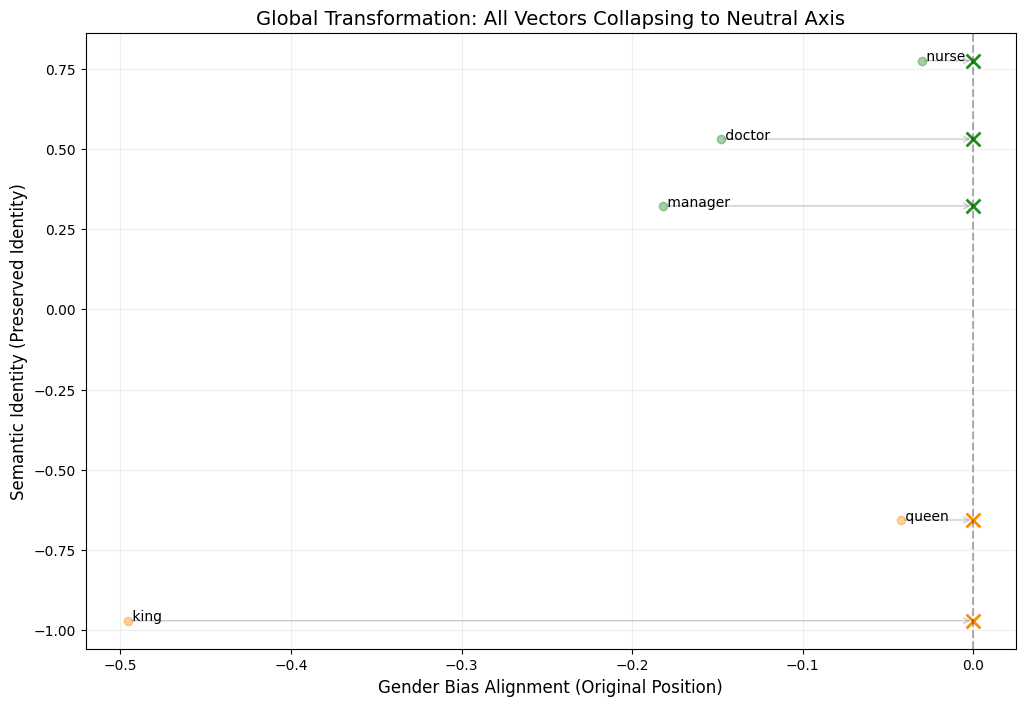

In [35]:
def plot_pca_comparison_enhanced(words, model, global_matrix, u_b):
    # 1. Get vectors
    orig_vecs = np.array([model[w] for w in words])
    new_vecs = np.array([global_matrix[model.key_to_index[w]] for w in words])
    
    # 2. Define the Coordinate System
    # X-axis: Alignment with Gender Axis (Projection)
    # Y-axis: PCA of the remaining semantic information
    def get_custom_coords(vecs):
        x = np.dot(vecs, u_b) # Component along gender axis
        residuals = vecs - np.outer(x, u_b) # Component orthogonal to gender
        pca = PCA(n_components=1)
        y = pca.fit_transform(residuals).flatten()
        return x, y

    x_orig, y_orig = get_custom_coords(orig_vecs)
    x_new, y_new = get_custom_coords(new_vecs)
    
    plt.figure(figsize=(12, 8))
    plt.axvline(0, color='black', linestyle='--', alpha=0.3, label="Neutral Axis")
    
    # 3. Plot words
    for i, word in enumerate(words):
        # Color-coding based on word type
        color = 'darkorange' if word in ['king', 'queen', 'mother'] else 'forestgreen'
        
        # Original point
        plt.scatter(x_orig[i], y_orig[i], c=color, marker='o', alpha=0.4)
        
        # Debiased point (all x_new[i] will be approx 0)
        plt.scatter(x_new[i], y_new[i], c=color, marker='x', s=100, linewidth=2)
        
        # Arrow showing the collapse to the neutral line
        plt.annotate('', xy=(x_new[i], y_new[i]), xytext=(x_orig[i], y_orig[i]),
                     arrowprops=dict(arrowstyle='->', color='gray', lw=1, alpha=0.4))
        
        plt.text(x_orig[i], y_orig[i], f" {word}", fontsize=10)

    plt.title("Global Transformation: All Vectors Collapsing to Neutral Axis", fontsize=14)
    plt.xlabel("Gender Bias Alignment (Original Position)", fontsize=12)
    plt.ylabel("Semantic Identity (Preserved Identity)", fontsize=12)
    plt.grid(True, alpha=0.2)
    plt.show()

# Run with the bias unit vector you defined earlier
plot_pca_comparison_enhanced(["doctor", "nurse", "manager", "queen", "king"], model, global_matrix_debiased, u_b)